# Final models comparison and summary

### Dependencies loading

In [7]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
import pickle
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 500)
pd.set_option('display.max_rows', 150)

# np.random.seed(1916) #uncomment if you want your code to be reproducible; for the purposes of our activity, let's add some randomness to the results

### Final models comparison

Now we have to use our 6 models to score our test set!

#### Naive Model

In case of Naive Model we have already scored our test set!

In [8]:
naive_model_score = pd.read_csv("../data/models_output/naive.csv", index_col = 0)

In [9]:
naive_model_score.rename(index={0: 'naive_model'},inplace=True)

In [10]:
naive_model_score

,RMSE,MAE
naive_model,0.16786,0.091059


#### OLS

In [11]:
df_train = pd.read_csv("../data/output/train_fe.csv", index_col=0)
df_test = pd.read_csv("../data/output/test_fe.csv", index_col=0)

In [12]:
X = ['adv_cat_(874.5, inf]', 'diff_positive', 'str_cat_(0.0875, 0.192]', 'ta_log', 'WB_GDPpc', 'txt_cat_(0.488, 24.415]', 'txt_cat_(-34.811, 0.488]', 'gielda_2', 'ppe_clip', 'revenue_cat_(1248.817, 4233.587]', 'revenue_cat_(4233.587, inf]', 'pi_cat_(8108.5, inf]', 'revenue_cat_(0.174, 1248.817]', 'roa_clip', 'pi_cat_(-8975.0, -1.523]', 'pi_cat_(157.119, 465.9]', 'pi_cat_(465.9, 7875.5]', 'pi_cat_(-1.523, 157.119]']

In [13]:
model = pickle.load(open("../models/ols.sav", 'rb'))

In [14]:
y_pred = model.predict(df_test.loc[:,X].values)

In [15]:
y_true = df_test.etr.tolist()
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)
ols_model_score = pd.DataFrame([rmse, mae]).T.rename(columns ={0:"RMSE", 1:"MAE"})

In [78]:
comp = pd.DataFrame([y_pred, y_true]).rename({0:"y_pred", 1:"y_true"}).T
plt.figure(figsize=(10, 5))
sns.jointplot(comp.y_pred, comp.y_true, kind="reg", truncate=False,)

TypeError: jointplot() takes from 0 to 1 positional arguments but 2 positional arguments (and 1 keyword-only argument) were given

<Figure size 1000x500 with 0 Axes>

In [79]:
ols_model_score.rename(index={0: 'ols_model'},inplace=True)

In [80]:
ols_model_score

,RMSE,MAE
ols_model,0.085129,0.061867


#### ARMA

In case of ARMA we have already scored our test set!

In [81]:
arma_model_score = pd.read_csv("../data/models_output/arma.csv", index_col = 0)

In [82]:
arma_model_score.rename(index={0: 'arma_model'},inplace=True)

In [83]:
arma_model_score

,RMSE,MAE
arma_model,0.115057,0.073336


#### ARDL

In [84]:
df_train = pd.read_csv("../data/output/train_fe.csv", index_col=0)
df_test = pd.read_csv("../data/output/test_fe.csv", index_col=0)

In [85]:
X = ['sale', 'cfc', 'txt_cat_(-34.811, 0.488]', 'txt_cat_(0.488, 24.415]',
       'txt_cat_(308.55, 327.531]', 'pi_cat_(7875.5, 8108.5]',
       'str_cat_(0.28, inf]', 'dlc_cat_(176.129, 200.9]', 'diff_positive',
       'etr_y_ma']

In [86]:
model = pickle.load(open("../models/ardl.sav", 'rb'))

In [87]:
y_pred = model.predict(df_test.loc[:,X].values)

In [88]:
y_true = df_test.etr.tolist()
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)
ardl_model_score = pd.DataFrame([rmse, mae]).T.rename(columns ={0:"RMSE", 1:"MAE"})

In [89]:
comp = pd.DataFrame([y_pred, y_true]).rename({0:"y_pred", 1:"y_true"}).T
plt.figure(figsize=(10, 5))
sns.jointplot(comp.y_pred, comp.y_true, kind="reg", truncate=False,)

TypeError: jointplot() takes from 0 to 1 positional arguments but 2 positional arguments (and 1 keyword-only argument) were given

<Figure size 1000x500 with 0 Axes>

In [90]:
ardl_model_score.rename(index={0: 'ardl_model'},inplace=True)

In [91]:
ardl_model_score

,RMSE,MAE
ardl_model,0.082121,0.05862


#### KNN

In [92]:
df_train = pd.read_csv("../data/output/train_fe.csv", index_col=0)
df_test = pd.read_csv("../data/output/test_fe.csv", index_col=0)

In [93]:
X = ['ta', 'txt', 'pi', 'str', 'xrd', 'ni', 'ppent', 'intant', 'dlc', 'dltt', 'capex', 'revenue', 'cce', 'adv', 'diff', 'roa', 'lev', 'intan', 'rd', 'ppe', 'sale', 'cash_holdings', 'adv_expenditure', 'capex2', 'cfc', 'dta', 'y_v2x_polyarchy', 'WB_GDPgrowth', 'WB_GDPpc', 'WB_Inflation', 'rr_per_country', 'rr_per_sector', 'etr_y_past', 'etr_y_ma', 'diff_ma', 'roa_ma', 'lev_ma', 'intan_ma', 'ppe_ma', 'sale_ma', 'cash_holdings_ma', 'roa_past', 'lev_past', 'intan_past', 'ppe_past', 'sale_past', 'cash_holdings_past']
standardization = ['rok', 'ta', 'txt', 'pi', 'str', 'xrd', 'ni', 'ppent', 'intant', 'dlc', 'dltt', 'capex', 'revenue', 'cce', 'adv', 'diff', 'roa', 'lev', 'intan', 'rd', 'ppe', 'sale', 'cash_holdings', 'adv_expenditure', 'capex2', 'capex2_scaled', 'y_v2x_polyarchy', 'WB_GDPgrowth', 'WB_GDPpc', 'WB_Inflation', 'rr_per_country', 'rr_per_sector', 'ta_log', 'ppent_sqrt', 'intant_sqrt', 'roa_clip', 'lev_sqrt', 'intan_pow2', 'rd_sqrt', 'ppe_clip', 'cash_holdings_sqrt', 'diff_dta', 'etr_y_past', 'etr_y_ma', 'diff_ma', 'roa_ma', 'lev_ma', 'intan_ma', 'ppe_ma', 'sale_ma', 'cash_holdings_ma', 'roa_past', 'lev_past', 'intan_past', 'ppe_past', 'sale_past', 'cash_holdings_past', 'y_e_p_polity']

In [94]:
scaler = pickle.load(open("../models/minmaxscaler.sav", 'rb'))
df_test[standardization] = scaler.transform(df_test[standardization])

In [95]:
model = pickle.load(open("../models/knn.sav", 'rb'))

In [96]:
y_pred = model.predict(df_test.loc[:,X].values)
y_pred

array([0.15381768, 0.14548521, 0.36528674, 0.16766692, 0.18747688,
       0.20035358, 0.19752034, 0.20237613, 0.39314654, 0.19300135,
       0.33345822, 0.3296713 , 0.28701783, 0.09736033, 0.26823414,
       0.28654306, 0.3241411 , 0.30037981, 0.29695114, 0.47406234,
       0.07206431, 0.17674928, 0.09264793, 0.12225917, 0.18816236,
       0.20352299, 0.10736068, 0.12256565, 0.17945494, 0.34148471,
       0.18061057, 0.33542907, 0.09570639, 0.15555886, 0.2491224 ,
       0.3027646 , 0.49428015, 0.19197748, 0.232559  , 0.18817675,
       0.28471094, 0.21752146, 0.19842386, 0.17789764, 0.17756358,
       0.29387459, 0.34024142, 0.10459147, 0.20729895, 0.33207707,
       0.3157007 , 0.28489943, 0.27884077, 0.25935849, 0.39578361,
       0.23638513, 0.18821065, 0.19634532, 0.16314053, 0.20292084,
       0.16481602, 0.22349722, 0.16935729, 0.3275025 , 0.16886608,
       0.23720305, 0.18902764, 0.15396119, 0.11922853, 0.11875531,
       0.18391152, 0.30255954, 0.23092748, 0.20505301, 0.47802

In [97]:
y_true = df_test.etr.tolist()
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)
knn_model_score = pd.DataFrame([rmse, mae]).T.rename(columns ={0:"RMSE", 1:"MAE"})

In [98]:
comp = pd.DataFrame([y_pred, y_true]).rename({0:"y_pred", 1:"y_true"}).T
plt.figure(figsize=(10, 5))
sns.jointplot(comp.y_pred, comp.y_true, kind="reg", truncate=False,)

TypeError: jointplot() takes from 0 to 1 positional arguments but 2 positional arguments (and 1 keyword-only argument) were given

<Figure size 1000x500 with 0 Axes>

In [38]:
knn_model_score.rename(index={0: 'knn_model'},inplace=True)

In [39]:
knn_model_score

,RMSE,MAE
knn_model,0.094528,0.06713


#### SVR

In [40]:
df_train = pd.read_csv("../data/output/train_fe.csv", index_col=0)
df_test = pd.read_csv("../data/output/test_fe.csv", index_col=0)

In [41]:
X = ['ta', 'pi', 'str', 'xrd', 'dlc', 'capex', 'revenue', 'cce', 'diff', 'sale', 'cash_holdings', 'capex2', 'cfc', 'capex2_scaled', 'WB_GDPpc', 'rr_per_country', 'rr_per_sector', 'sektor_consumer discretionary', 'sektor_consumer staples', 'sektor_energy', 'sektor_health care', 'sektor_industrials', 'sektor_materials', 'sektor_real estate', 'gielda_2', 'gielda_3', 'xrd_exists', 'ni_profit', 'ni_profit_20000', 'diff_positive', 'lev_sqrt', 'etr_y_ma', 'lev_ma', 'lev_past', 'sale_past', 'cash_holdings_past']
standardization = ['rok', 'ta', 'txt', 'pi', 'str', 'xrd', 'ni', 'ppent', 'intant', 'dlc', 'dltt', 'capex', 'revenue', 'cce', 'adv', 'diff', 'roa', 'lev', 'intan', 'rd', 'ppe', 'sale', 'cash_holdings', 'adv_expenditure', 'capex2', 'capex2_scaled', 'y_v2x_polyarchy', 'WB_GDPgrowth', 'WB_GDPpc', 'WB_Inflation', 'rr_per_country', 'rr_per_sector', 'ta_log', 'ppent_sqrt', 'intant_sqrt', 'roa_clip', 'lev_sqrt', 'intan_pow2', 'rd_sqrt', 'ppe_clip', 'cash_holdings_sqrt', 'diff_dta', 'etr_y_past', 'etr_y_ma', 'diff_ma', 'roa_ma', 'lev_ma', 'intan_ma', 'ppe_ma', 'sale_ma', 'cash_holdings_ma', 'roa_past', 'lev_past', 'intan_past', 'ppe_past', 'sale_past', 'cash_holdings_past', 'y_e_p_polity']

In [99]:
scaler = pickle.load(open("../models/standardscaler.sav", 'rb'))
df_test[standardization] = scaler.transform(df_test[standardization])

In [100]:
model = pickle.load(open("../models/svr.sav", 'rb'))

In [101]:
y_pred = model.predict(df_test.loc[:,X].values)
y_pred

ValueError: X has 47 features, but SVR is expecting 36 features as input.

In [45]:
y_true = df_test.etr.tolist()
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)
svr_model_score = pd.DataFrame([rmse, mae]).T.rename(columns ={0:"RMSE", 1:"MAE"})

In [46]:
comp

,y_pred,y_true
0,0.153818,0.214678
1,0.145485,0.169561
2,0.365287,0.138719
3,0.167667,0.262670
4,0.187477,0.451843
...,...,...
358,0.221747,0.262860
359,0.101142,0.057970
360,0.346505,0.420331
361,0.183279,0.290330


In [47]:
comp = pd.DataFrame([y_pred, y_true]).rename({0:"y_pred", 1:"y_true"}).T
plt.figure(figsize=(10, 5))
sns.jointplot(comp.y_pred, comp.y_true, kind="reg", truncate=False,)

TypeError: jointplot() takes from 0 to 1 positional arguments but 2 positional arguments (and 1 keyword-only argument) were given

<Figure size 1000x500 with 0 Axes>

In [48]:
svr_model_score.rename(index={0: 'svr_model'},inplace=True)

In [49]:
svr_model_score

,RMSE,MAE
svr_model,0.084485,0.061772


### Final comparison and summary

In [50]:
final_comparison = pd.concat([naive_model_score, ols_model_score, arma_model_score, ardl_model_score, knn_model_score, svr_model_score])

In [102]:
final_comparison.sort_values("RMSE")

,RMSE,MAE
GBM,0.077476,NaN
CatBoost,0.077982,NaN
HistGBM,0.078303,NaN
XGBoostLSS,0.078527,NaN
LightGBM,0.078790,NaN
ARDL,0.082121,0.058620
AdaBoost,0.084005,NaN
SVR,0.084485,0.061772
OLS,0.085129,0.061867
KNN,0.094528,0.067130


In [103]:
final_comparison.rename({"knn_model":"KNN", "svr_model":"SVR", "ardl_model":"ARDL", "ols_model":"OLS", "arma_model":"ARMA", "naive_model":"NAIVE MODEL"},inplace=True)

In [104]:
final_comparison = final_comparison.round(6)

In [105]:
final_comparison

,RMSE,MAE
GBM,0.077476,NaN
CatBoost,0.077982,NaN
HistGBM,0.078303,NaN
XGBoostLSS,0.078527,NaN
LightGBM,0.078790,NaN
ARDL,0.082121,0.058620
AdaBoost,0.084005,NaN
SVR,0.084485,0.061772
OLS,0.085129,0.061867
KNN,0.094528,0.067130


[]

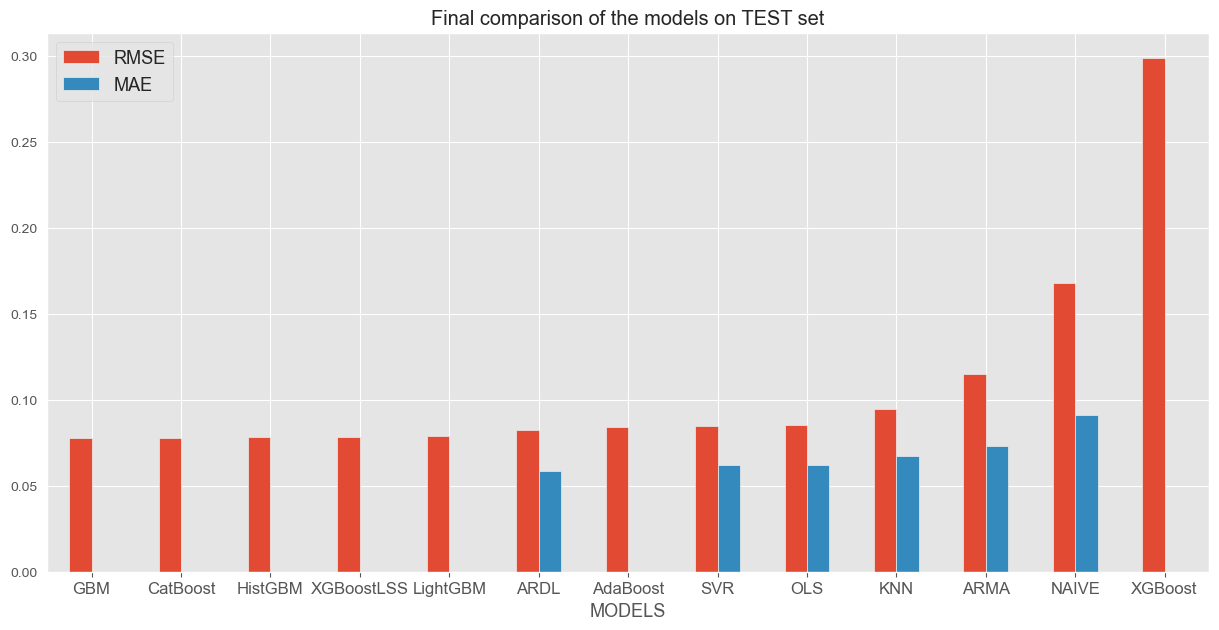

In [106]:
plt.style.use('ggplot')
ax = final_comparison.plot(kind='bar', figsize=(15, 7), title="Final comparison of the models on TEST set")
ax.legend(fontsize=13)
plt.tick_params(
    axis='x',          # changes apply to the x-axis
    which='both',      # both major and minor ticks are affected
    bottom=True,      # ticks along the bottom edge are off
    top=False,         # ticks along the top edge are off
    labelbottom=True, ) # labels along the bottom edge are off
ax.set_xticklabels(final_comparison.index, rotation=0, fontsize=12)
ax.set_xlabel("MODELS", fontsize=13)
ax.plot()

And the winner is: **ARDL**, but we see that OLS and SVR were very close.

#### Final summary

Based on final scores we see that: 
 * naive model ($y_t = y_{t-1}$) have been  beaten by all models
 * ARMA approach without additional exogenous variables was better than naive model
 * OLS approach without additional time-related exogenous variables was better than naive model
 * when we combined both approaches: static exogenous variables + time-related exogenous variables in ARDL model we obtained better model!
 * SVR and KNN are weaker than econometric approaches

**To be honest in most cases in the business environment for sure we will chose ARDL: cheaper - computational time; fully explainable and has less variables!**

## Compare boosting models with traditional models

In [ ]:
import xgboost as xgb
import os
import re

# LSS loading check
try:
    from xgboostlss.model import XGBoostLSS
    from xgboostlss.distributions.Gaussian import Gaussian
    from xgboostlss.distributions.StudentT import StudentT
    HAS_LSS = True
except ImportError:
    HAS_LSS = False


In [107]:
# Load Test Data specifically for GB models (Need column name cleaning!)
df_test_gb = pd.read_csv("../data/output/test_fe.csv", index_col=0)
# Apply the same regex cleaning we used during training
df_test_gb.columns = [re.sub(r'[^A-Za-z0-9_]+', '_', c) for c in df_test_gb.columns]
y_true = df_test_gb['etr'].tolist()

models_dir = "../models"
gb_scores_list = []

Processing XGBoostLSS...
--- XGBoostLSS (RMSE: 0.0785) ---


<Figure size 1000x500 with 0 Axes>

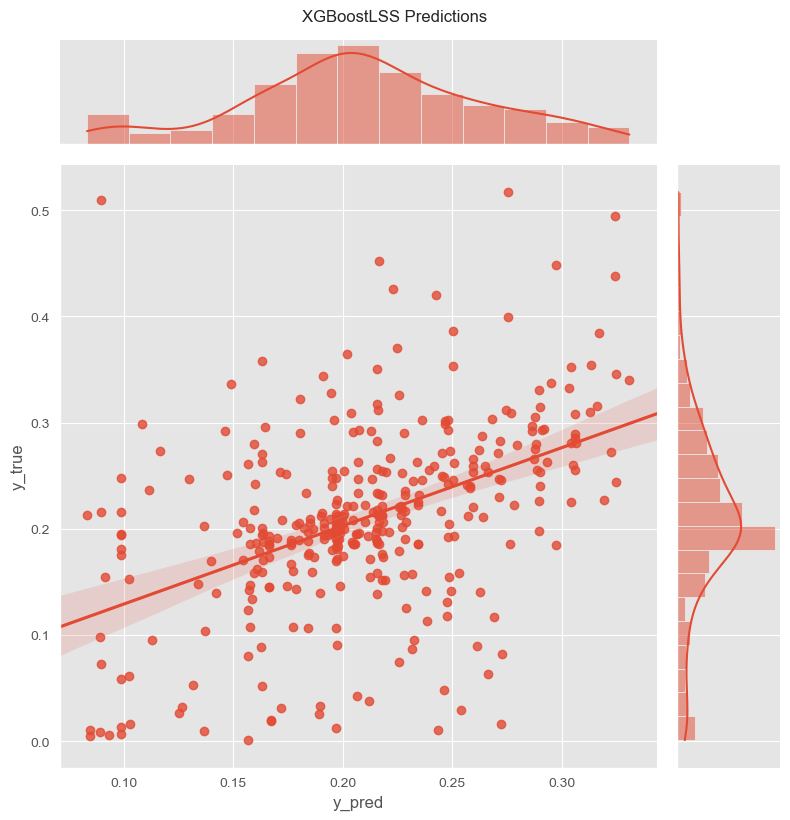

Processing CatBoost...
--- CatBoost (RMSE: 0.0780) ---


<Figure size 1000x500 with 0 Axes>

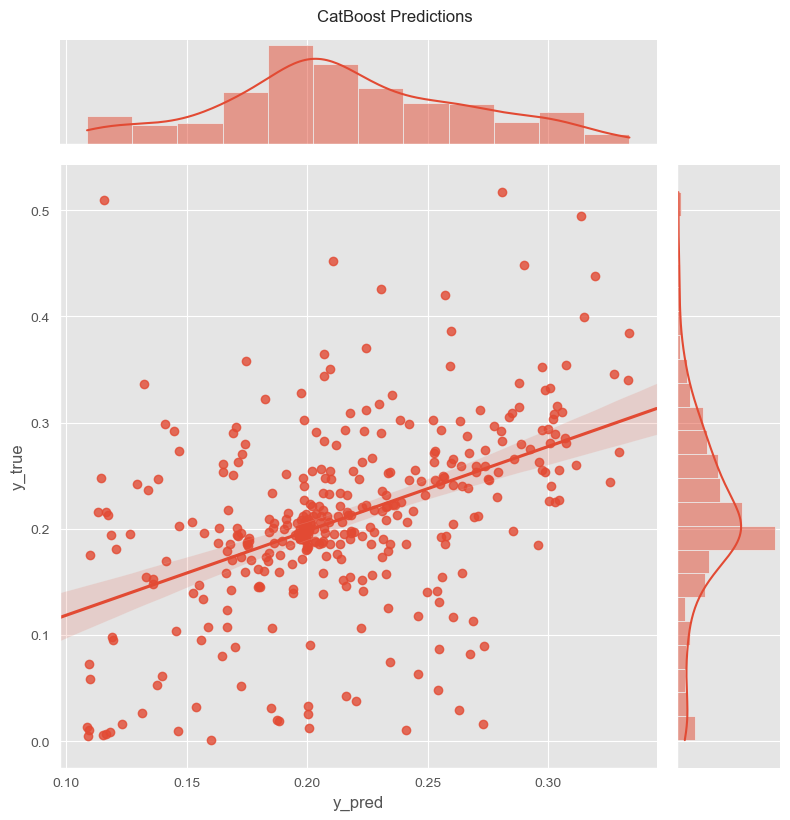

Processing AdaBoost...
--- AdaBoost (RMSE: 0.0840) ---


<Figure size 1000x500 with 0 Axes>

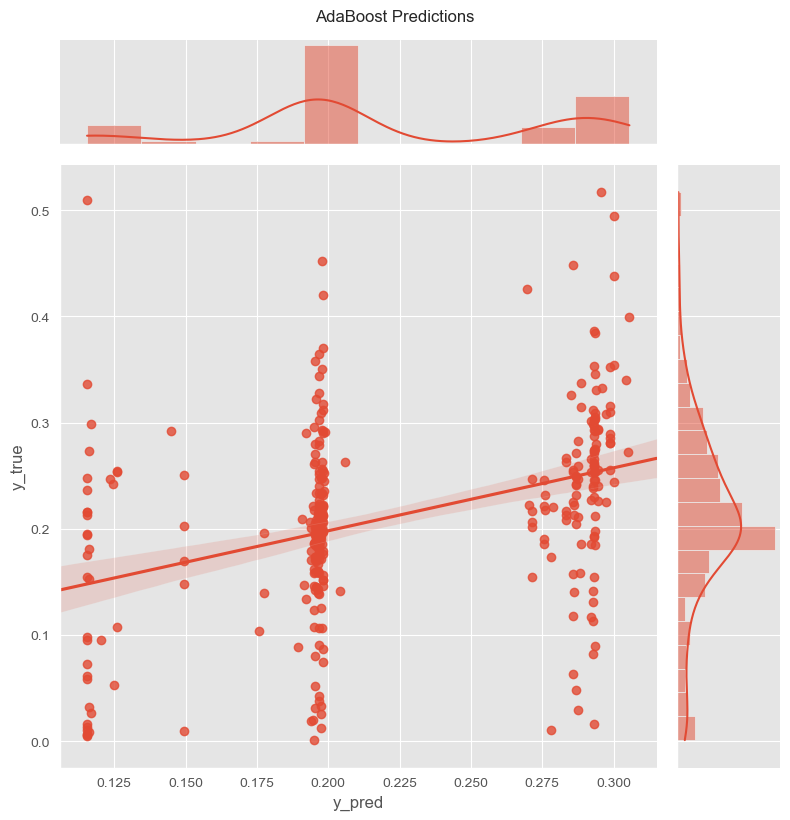

Processing HistGBM...
--- HistGBM (RMSE: 0.0783) ---


<Figure size 1000x500 with 0 Axes>

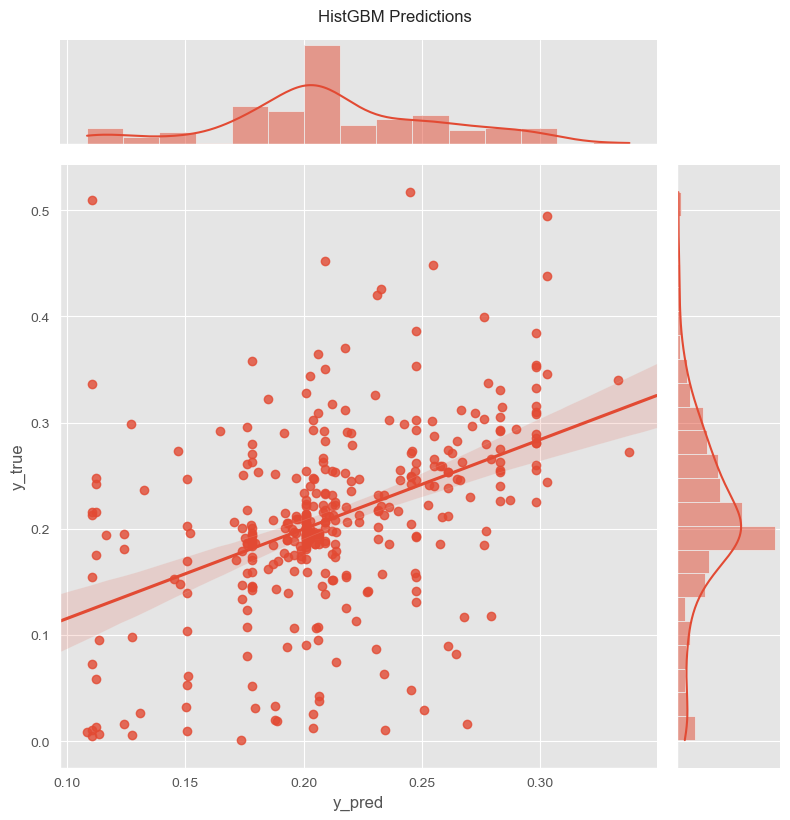

Processing XGBoost...
--- XGBoost (RMSE: 0.2987) ---


<Figure size 1000x500 with 0 Axes>

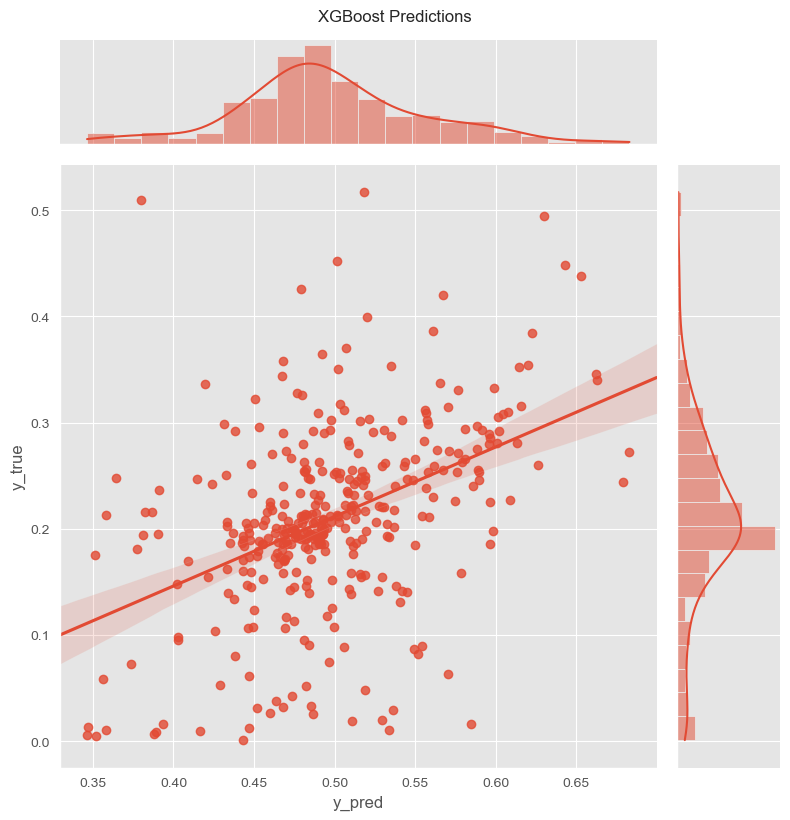

Processing GBM...
--- GBM (RMSE: 0.0775) ---


<Figure size 1000x500 with 0 Axes>

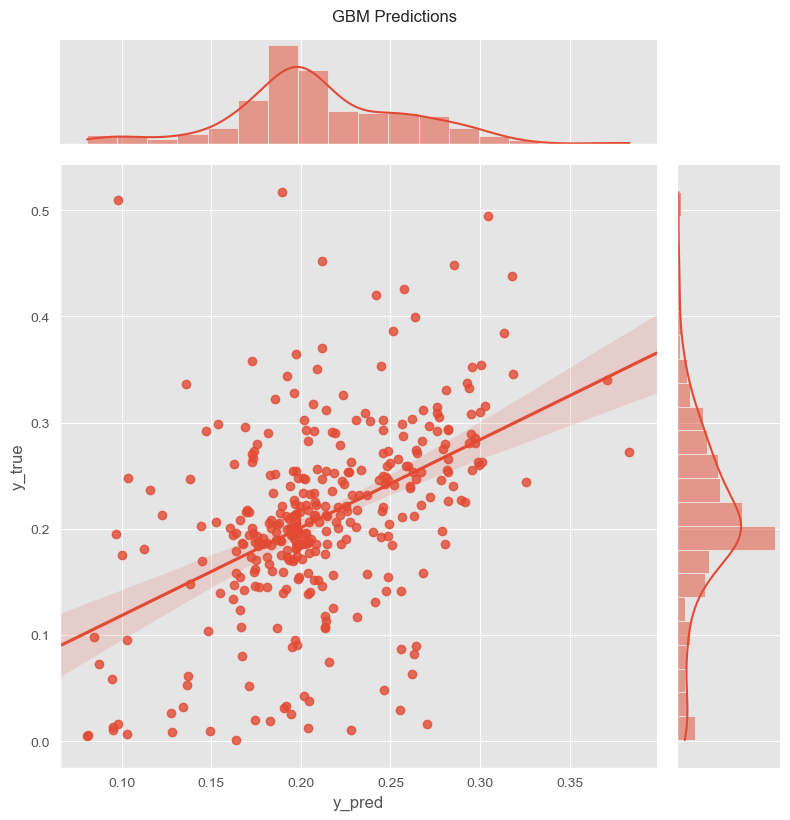

Processing LightGBM...
--- LightGBM (RMSE: 0.0788) ---


<Figure size 1000x500 with 0 Axes>

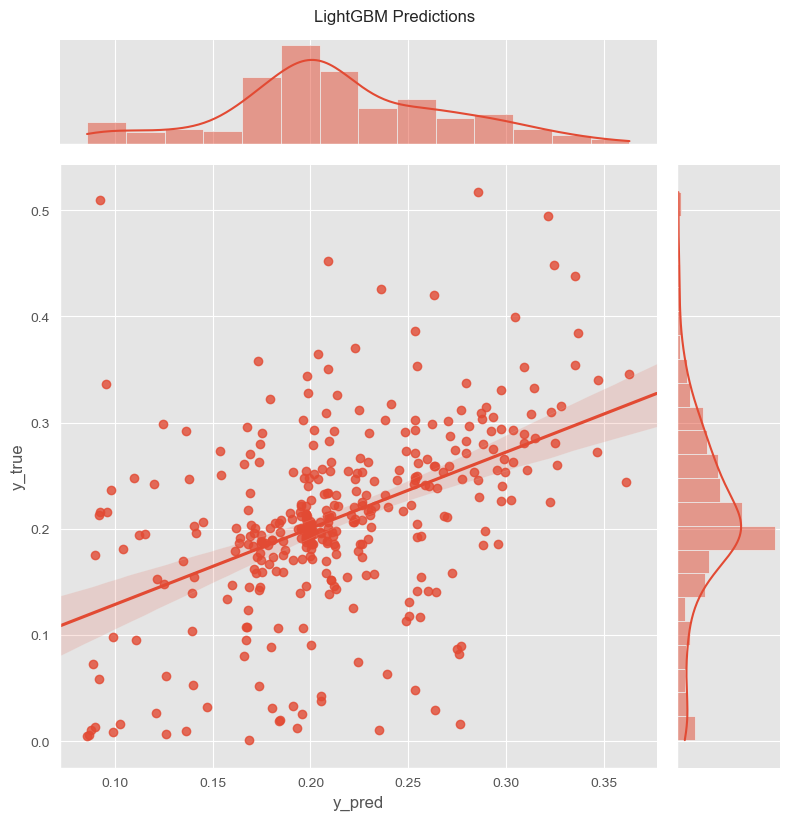

,RMSE,MAE
XGBoostLSS,0.078527,0.053751
CatBoost,0.077982,0.053412
AdaBoost,0.084005,0.058966
HistGBM,0.078303,0.053147
XGBoost,0.298661,0.288320
GBM,0.077476,0.052342
LightGBM,0.078790,0.053894


In [108]:
# Iterate over all saved best models
gb_model_files = [f for f in os.listdir(models_dir) if f.endswith('_best.pkl')]

for filename in gb_model_files:
    model_name = filename.replace('_best.pkl', '')
    filepath = os.path.join(models_dir, filename)

    print(f"Processing {model_name}...")

    try:
        # 1. Load Model Object
        with open(filepath, 'rb') as f:
            saved_obj = pickle.load(f)

        # Extract Metadata
        if isinstance(saved_obj, dict) and "model" in saved_obj:
            model_instance = saved_obj["model"]
            features = saved_obj["features"]
            cat_cols = saved_obj.get("cat_cols", [])
            model_type = saved_obj.get("type", "Standard")
            wrapper = saved_obj.get("wrapper", None)
        else:
            # Fallback for older pickle formats
            model_instance = saved_obj
            features = [c for c in df_test_gb.columns if c != 'etr']
            cat_cols = []
            model_type = "Standard"

        # 2. Prepare Features (X)
        X_test_sub = df_test_gb[features].copy()

        # Handle Categorical Types (Important for LightGBM/XGBoost)
        if model_name in ["LightGBM", "XGBoost", "XGBoostLSS", "CatBoost"] or "LGBM" in str(type(model_instance)):
            for col in cat_cols:
                if col in X_test_sub.columns:
                    X_test_sub[col] = X_test_sub[col].astype('category')

        # 3. Predict (y_pred)
        y_pred = None
        if model_type == "LSS" and HAS_LSS:
            dtest = xgb.DMatrix(X_test_sub, enable_categorical=True)
            pred_params = wrapper.predict(dtest, pred_type="parameters")
            y_pred = pred_params["loc"].values  # Mean prediction
        else:
            y_pred = model_instance.predict(X_test_sub)

        # 4. Calculate Scores (RMSE, MAE)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        mae = mean_absolute_error(y_true, y_pred)

        # Save score to list (similar to your _model_score dataframes)
        score_df = pd.DataFrame([rmse, mae]).T.rename(columns={0: "RMSE", 1: "MAE"})
        score_df.rename(index={0: model_name}, inplace=True)
        gb_scores_list.append(score_df)

        # 5. Visualization (JointPlot) - Mimicking your style
        print(f"--- {model_name} (RMSE: {rmse:.4f}) ---")
        comp = pd.DataFrame([y_pred, y_true]).rename({0: "y_pred", 1: "y_true"}).T

        plt.figure(figsize=(10, 5))
        g = sns.jointplot(
            data=comp,
            x="y_pred",
            y="y_true",
            kind="reg",
            truncate=False,
            height=8  # Optional adjustment
        )
        g.fig.suptitle(f"{model_name} Predictions", y=1.02)
        plt.show()

    except Exception as e:
        print(f"Skipping {model_name}: {e}")

# Combine all GB scores into one DataFrame
if gb_scores_list:
    gb_models_score = pd.concat(gb_scores_list)
else:
    gb_models_score = pd.DataFrame()

gb_models_score

### Final comparison and summary

🏆 Final Cleaned Leaderboard:
                RMSE       MAE
GBM         0.077476  0.052342
CatBoost    0.077982  0.053412
HistGBM     0.078303  0.053147
XGBoostLSS  0.078527  0.053751
LightGBM    0.078790  0.053894
ARDL        0.082121  0.058620
AdaBoost    0.084005  0.058966
SVR         0.084485  0.061772
OLS         0.085129  0.061867
0           0.094528  0.067130
ARMA        0.115057  0.073336
NAIVE       0.167860  0.091059
XGBoost     0.298661  0.288320


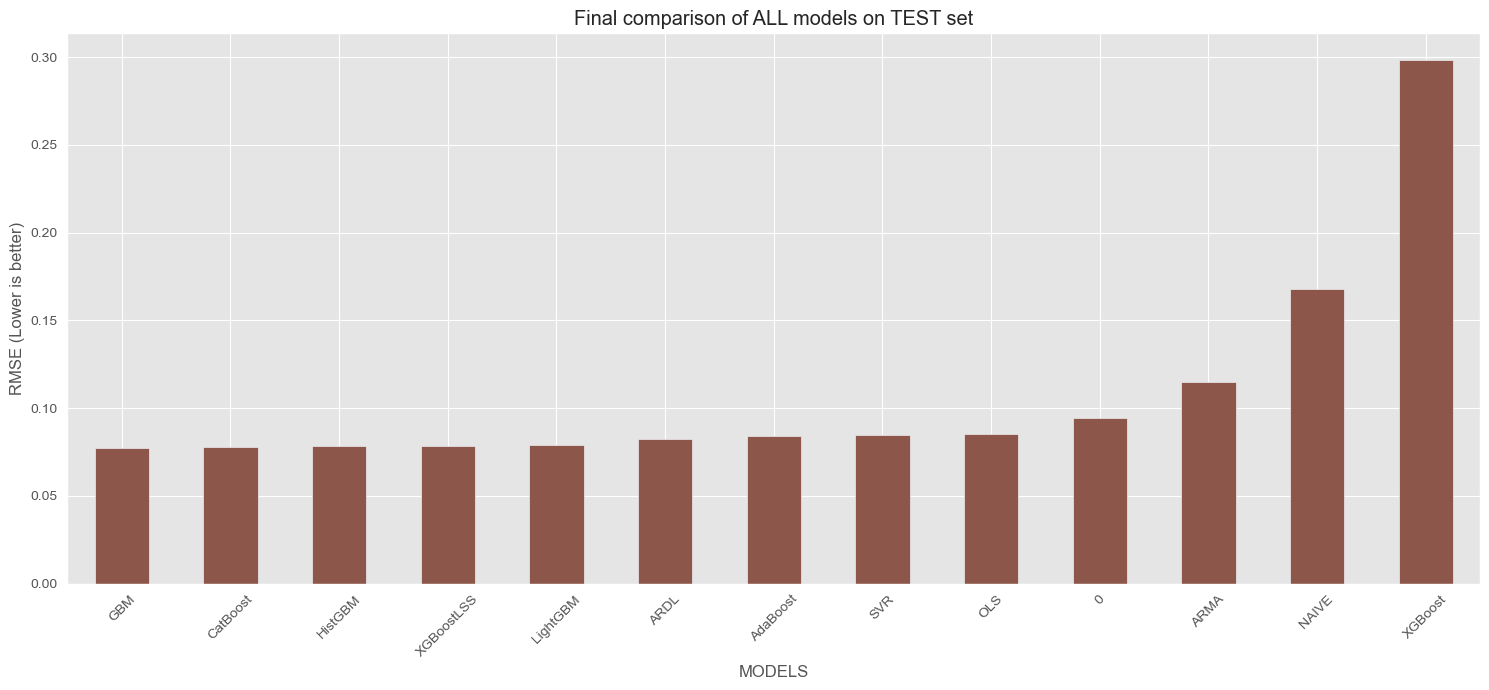

The absolute winner is: **GBM** with RMSE: 0.077476
Conclusion: Machine Learning (Gradient Boosting) models outperformed traditional Econometric models!


In [109]:

# 1. Combine Old Models and New Gradient Boosting Models
final_comparison = pd.concat([
    naive_model_score,
    ols_model_score,
    arma_model_score,
    ardl_model_score,
    knn_model_score,
    svr_model_score,
    gb_models_score
])

# 2. Remove Duplicates (Critical Step)
final_comparison = final_comparison[~final_comparison.index.duplicated(keep='first')]

# 3. Rename indices for better plotting
rename_dict = {
    "knn_model": "KNN", "svr_model": "SVR", "ardl_model": "ARDL",
    "ols_model": "OLS", "arma_model": "ARMA", "naive_model": "NAIVE"
}
final_comparison.rename(index=rename_dict, inplace=True)

# 4. Sort & Round
final_comparison.sort_values("RMSE", inplace=True)
final_comparison = final_comparison.round(6)

# Display the cleaned table
print("🏆 Final Cleaned Leaderboard:")
print(final_comparison)

# 5. Plotting
plt.style.use('ggplot')
ax = final_comparison["RMSE"].plot(
    kind='bar',
    figsize=(15, 7),
    title="Final comparison of ALL models on TEST set",
    color='#8c564b'  # Brownish color
)

plt.ylabel("RMSE (Lower is better)")
plt.xlabel("MODELS")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Final Verdict
best_model = final_comparison.index[0]
best_score = final_comparison.iloc[0]["RMSE"]

print(f"The absolute winner is: **{best_model}** with RMSE: {best_score}")
